In [5]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


# Load the data 
df = pd.read_csv('/kaggle/input/datasets/bumba5341/advertisingcsv/Advertising.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

# Drop unnamed index column if exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Check column names 
print("\nDataset Info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Dataset Shape: (200, 5)

First 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Column names: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Summary statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809  

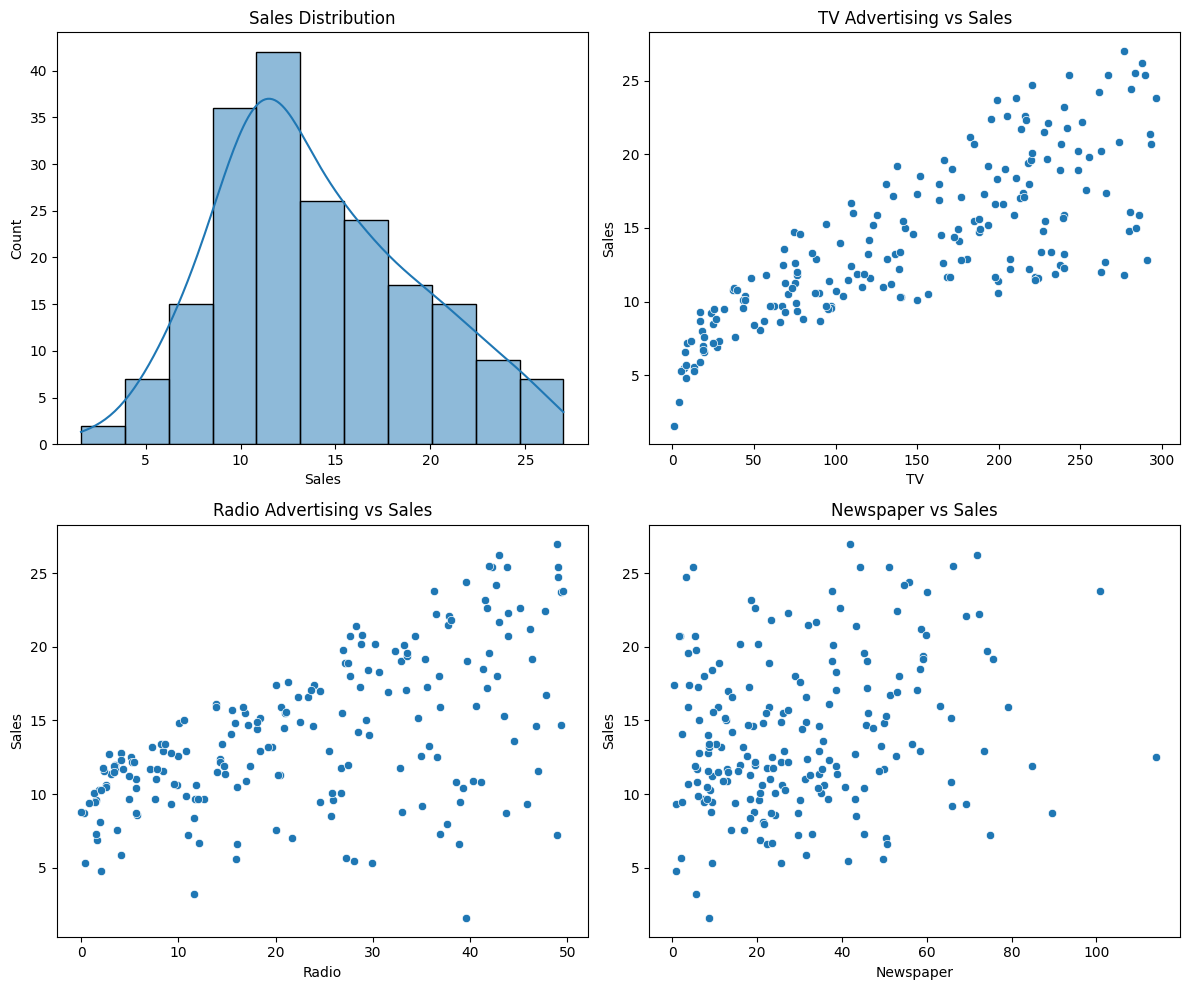

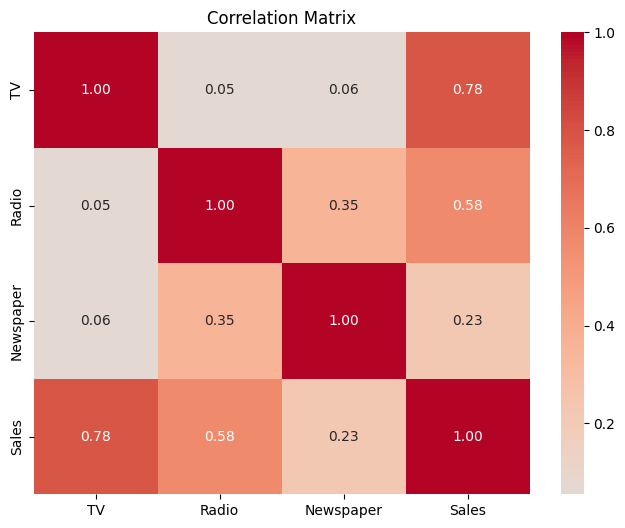

In [6]:
# Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sales distribution
sns.histplot(df['Sales'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution')

# TV vs Sales
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0, 1])
axes[0, 1].set_title('TV Advertising vs Sales')

# Radio vs Sales
sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1, 0])
axes[1, 0].set_title('Radio Advertising vs Sales')

# Newspaper vs Sales
sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[1, 1])
axes[1, 1].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [7]:
# Feature Engineering
# Create interaction features
df['TV_Radio'] = df['TV'] * df['Radio']
df['TV_Newspaper'] = df['TV'] * df['Newspaper']

# Prepare features
feature_cols = ['TV', 'Radio', 'Newspaper', 'TV_Radio', 'TV_Newspaper']
X = df[feature_cols]
y = df['Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [8]:
print("\n=== Model Performance ===")
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'CV_Mean': cv_scores.mean()}
    
    print(f"\n{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  CV R²: {cv_scores.mean():.4f}")

# Best model - Random Forest
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)


=== Model Performance ===

Linear Regression:
  R² Score: 0.9753
  RMSE: 0.88
  MAE: 0.66
  CV R²: 0.9489

Ridge Regression:
  R² Score: 0.9746
  RMSE: 0.90
  MAE: 0.66
  CV R²: 0.9497

Random Forest:
  R² Score: 0.9894
  RMSE: 0.58
  MAE: 0.44
  CV R²: 0.9851

Gradient Boosting:
  R² Score: 0.9912
  RMSE: 0.53
  MAE: 0.38
  CV R²: 0.9876


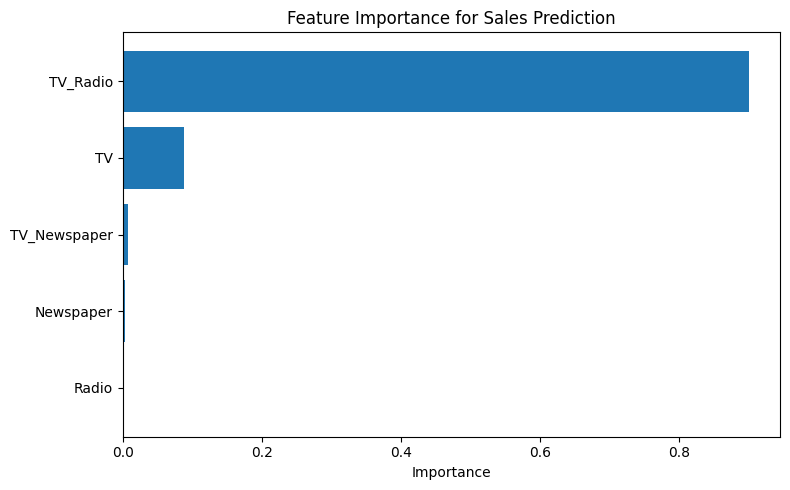

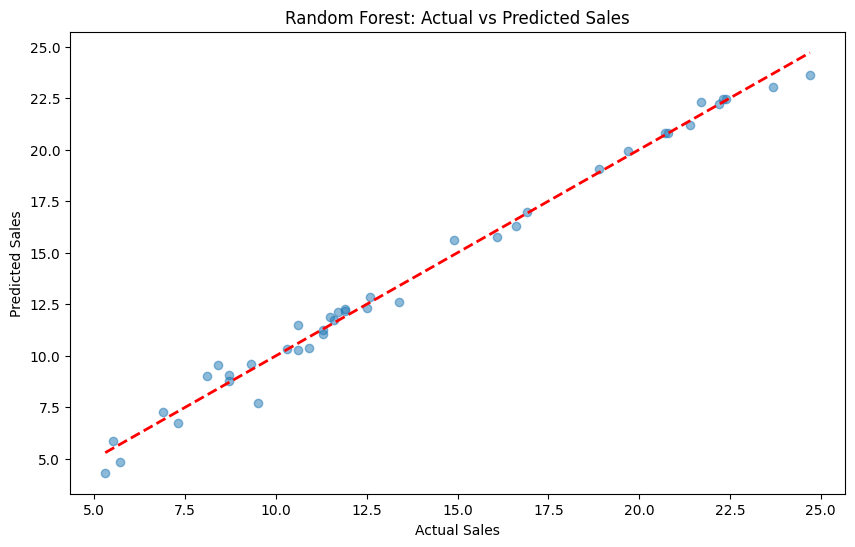


=== Advertising Impact Analysis ===
TV coefficient: 1.7543
Radio coefficient: 0.3777
Newspaper coefficient: 0.3022


In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Sales Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Predictions vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.show()

# Advertising impact analysis
print("\n=== Advertising Impact Analysis ===")
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

for i, col in enumerate(feature_cols):
    if col in ['TV', 'Radio', 'Newspaper']:
        print(f"{col} coefficient: {linear_model.coef_[i]:.4f}")
